ROC Curve: Shows correctly flagged defaulters to incorrectly flagged non-defaulters for every possible cutoff PD [Cutoff PD = probability of default above which person is classified a defaulter]

AUC (Area Under Curve): does the model give a higher PD to an actual defaulter than a non-defaulter? ranges from 0.5 (half the time, random, knows nothing) to 1 (is good)

GINI : 2(AUC) - 1, same thing scaled differently, 0.5 AUC = O GINI, 1 AUC = 1 GINI, rescales AUC [0.5,1] to [0,1]

KS Curve: shows how well defaulters and repayers separate as you increase the score.  single biggest gap between the two groups' cumulative curves. If the KS is 0, it means theyre not really separated, 30-50 is healthy, and 70+ is suspiciously too good

WOE : straight line cannot capture if variable has a non-linear relationship with the default probability. So you split the variable into brackets and see what % of defaulters and repayers they hold of total. 
WOE = log[% good / % bad], if the WOE is negative, bad; if it is positive, healthy  [this flips if the formula is bad/good]

IV: Tells you how good the variable finally is, does it actually differentiate between defaulters and repayers? under 0.02 = bad, 0.1 to 0.3 decent, 0.3 to 0.5 good, 0.5+ too good

Log Odds: log[p/(1-p)], near 0 is safe, 0 is 50-50, high +ve numbers is risky 

Scorecard Scaling: 
1) Reference point: choose number for 50-50 odds (say, 600)
2) PDO and Offset: PDO is points needed to double the odds (say every 40 points, 50 to 1 -> 100 to 1 -> etc)
Factor = PDO / log(2)

Offset = Reference score - Factor x log(reference odds)

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn optbinning matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df1 = pd.read_csv("accepted_2007_to_2018Q4.csv.gz")

C:\Users\tanis\AppData\Local\Temp\ipykernel_11780\592436742.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("accepted_2007_to_2018Q4.csv.gz")


In [4]:
df1.shape

(2260701, 151)

In [5]:
df1.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)

In [6]:
df1['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

for the purposes of this project, "charged off" and "default" will be a part of category (1) and "fully paid" of cateogy (2). Others will be dropped.

In [7]:
keep_statuses = ["Charged Off", "Fully Paid", "Default"]
df = df1[df1["loan_status"].isin(keep_statuses)].copy()
bad_statuses = ["Charged Off", "Default"]
df["Target"] = df["loan_status"].isin(bad_statuses).astype(int)

In [8]:
df["Target"].value_counts()


Target
0    1076751
1     268599
Name: count, dtype: int64

In [9]:
df.shape

(1345350, 152)

Now, there will be a sorting of columns into ones that are known at time of application (to be kept), and ones that are recorded after origination or are irrelevant (to be dropped)

In [10]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

Adding the library to see what columns to keep and which ones to discard

In [11]:
dd = pd.read_csv("https://raw.githubusercontent.com/d-osei/Lending-Club-Loan-Data/master/LCDataDictionary.csv")

In [12]:

dd[dd["LoanStatNew"] == "inq_last_6mths"]


,LoanStatNew,Description
32,inq_last_6mths,The number of inquiries in past 6 months (excl...


These are the columns we will be working with, benchmark columns have been added to do robustness checks later. The grade and subgrade assigned by the banks will be used to do sanity checks.

In [13]:

model_features = [
    "loan_amnt", "term",
    "emp_length", "home_ownership", "annual_inc", "verification_status", "purpose",
    "addr_state", "dti",
    "delinq_2yrs", "earliest_cr_line", "fico_range_low", "fico_range_high",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies",
]

# kept aside as benchmark, NOT fed to the model
benchmark_cols = ["grade", "sub_grade", "int_rate", "installment"]

# keep both groups plus target in the working dataframe for now
df = df[model_features + benchmark_cols + ["Target"]].copy()

Checking for null values

In [14]:

(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

emp_length              5.836102
mort_acc                3.514401
revol_util              0.063701
pub_rec_bankruptcies    0.051808
dti                     0.027799
inq_last_6mths          0.000074
term                    0.000000
loan_amnt               0.000000
annual_inc              0.000000
home_ownership          0.000000
delinq_2yrs             0.000000
addr_state              0.000000
purpose                 0.000000
verification_status     0.000000
fico_range_high         0.000000
open_acc                0.000000
fico_range_low          0.000000
earliest_cr_line        0.000000
revol_bal               0.000000
pub_rec                 0.000000
total_acc               0.000000
grade                   0.000000
sub_grade               0.000000
int_rate                0.000000
installment             0.000000
Target                  0.000000
dtype: float64

In [15]:
df["emp_length"].value_counts(dropna=False)

emp_length
10+ years    442209
2 years      121751
< 1 year     108065
3 years      107602
1 year        88495
5 years       84154
4 years       80558
NaN           78516
6 years       62735
8 years       60704
7 years       59624
9 years       50937
Name: count, dtype: int64

In [16]:
df["dti"].describe()

count    1.344976e+06
mean     1.828264e+01
std      1.116041e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64

In [17]:
df["dti"].value_counts()

dti
18.00    995
19.20    991
14.40    972
16.80    951
15.60    918
        ... 
75.35      1
73.05      1
65.27      1
81.15      1
52.46      1
Name: count, Length: 7067, dtype: int64

In [18]:
df.describe()

,loan_amnt,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,int_rate,installment,Target
count,1.345350e+06,1.345350e+06,1.344976e+06,1.345350e+06,1.345350e+06,1.345350e+06,1.345349e+06,1.345350e+06,1.345350e+06,1.345350e+06,1.344493e+06,1.345350e+06,1.298069e+06,1.344653e+06,1.345350e+06,1.345350e+06,1.345350e+06
mean,1.441997e+04,7.624757e+04,1.828264e+01,3.177917e-01,6.961853e+02,7.001854e+02,6.550761e-01,1.159351e+01,2.152778e-01,1.624796e+04,5.180978e+01,2.498075e+01,1.670769e+00,1.344444e-01,1.323971e+01,4.380756e+02,1.996499e-01
std,8.717098e+03,6.992485e+04,1.116041e+01,8.779831e-01,3.185280e+01,3.185345e+01,9.377690e-01,5.473848e+00,6.018645e-01,2.232791e+04,2.452110e+01,1.199851e+01,2.000441e+00,3.779279e-01,4.768782e+00,2.615145e+02,3.997373e-01
min,5.000000e+02,0.000000e+00,-1.000000e+00,0.000000e+00,6.250000e+02,6.290000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00
25%,8.000000e+03,4.578000e+04,1.179000e+01,0.000000e+00,6.700000e+02,6.740000e+02,0.000000e+00,8.000000e+00,0.000000e+00,5.943000e+03,3.340000e+01,1.600000e+01,0.000000e+00,0.000000e+00,9.750000e+00,2.484800e+02,0.000000e+00
50%,1.200000e+04,6.500000e+04,1.761000e+01,0.000000e+00,6.900000e+02,6.940000e+02,0.000000e+00,1.100000e+01,0.000000e+00,1.113400e+04,5.220000e+01,2.300000e+01,1.000000e+00,0.000000e+00,1.274000e+01,3.754300e+02,0.000000e+00
75%,2.000000e+04,9.000000e+04,2.406000e+01,0.000000e+00,7.100000e+02,7.140000e+02,1.000000e+00,1.400000e+01,0.000000e+00,1.975500e+04,7.070000e+01,3.200000e+01,3.000000e+00,0.000000e+00,1.599000e+01,5.807300e+02,0.000000e+00
max,4.000000e+04,1.099920e+07,9.990000e+02,3.900000e+01,8.450000e+02,8.500000e+02,8.000000e+00,9.000000e+01,8.600000e+01,2.904836e+06,8.923000e+02,1.760000e+02,5.100000e+01,1.200000e+01,3.099000e+01,1.719830e+03,1.000000e+00


2 columns where i will be dropping values are dti and revol_util, where i only keep values between 0 and 100 in the dti column, and drop anything more than 150 in the revol_util column.

the max for revol_util goes up to 892%, i have kept values until a reasonable maximum of 150

In [19]:
df.loc[df["dti"] < 0,"dti"] = np.nan

In [20]:
df.loc[df["dti"] > 100,"dti"] = np.nan

In [21]:
df.loc[df["revol_util"] > 150, "revol_util"] = np.nan

In [22]:
df.describe()

,loan_amnt,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,int_rate,installment,Target
count,1.345350e+06,1.345350e+06,1.344441e+06,1.345350e+06,1.345350e+06,1.345350e+06,1.345349e+06,1.345350e+06,1.345350e+06,1.345350e+06,1.344473e+06,1.345350e+06,1.298069e+06,1.344653e+06,1.345350e+06,1.345350e+06,1.345350e+06
mean,1.441997e+04,7.624757e+04,1.818437e+01,3.177917e-01,6.961853e+02,7.001854e+02,6.550761e-01,1.159351e+01,2.152778e-01,1.624796e+04,5.180741e+01,2.498075e+01,1.670769e+00,1.344444e-01,1.323971e+01,4.380756e+02,1.996499e-01
std,8.717098e+03,6.992485e+04,8.678398e+00,8.779831e-01,3.185280e+01,3.185345e+01,9.377690e-01,5.473848e+00,6.018645e-01,2.232791e+04,2.450557e+01,1.199851e+01,2.000441e+00,3.779279e-01,4.768782e+00,2.615145e+02,3.997373e-01
min,5.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,6.250000e+02,6.290000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00
25%,8.000000e+03,4.578000e+04,1.179000e+01,0.000000e+00,6.700000e+02,6.740000e+02,0.000000e+00,8.000000e+00,0.000000e+00,5.943000e+03,3.340000e+01,1.600000e+01,0.000000e+00,0.000000e+00,9.750000e+00,2.484800e+02,0.000000e+00
50%,1.200000e+04,6.500000e+04,1.761000e+01,0.000000e+00,6.900000e+02,6.940000e+02,0.000000e+00,1.100000e+01,0.000000e+00,1.113400e+04,5.220000e+01,2.300000e+01,1.000000e+00,0.000000e+00,1.274000e+01,3.754300e+02,0.000000e+00
75%,2.000000e+04,9.000000e+04,2.405000e+01,0.000000e+00,7.100000e+02,7.140000e+02,1.000000e+00,1.400000e+01,0.000000e+00,1.975500e+04,7.070000e+01,3.200000e+01,3.000000e+00,0.000000e+00,1.599000e+01,5.807300e+02,0.000000e+00
max,4.000000e+04,1.099920e+07,1.000000e+02,3.900000e+01,8.450000e+02,8.500000e+02,8.000000e+00,9.000000e+01,8.600000e+01,2.904836e+06,1.480000e+02,1.760000e+02,5.100000e+01,1.200000e+01,3.099000e+01,1.719830e+03,1.000000e+00


The data is cleaned, now we will move on to splitting the data into testing and training splits. The two split sections of the data are the one i will use for training (80%) and for testing the model on (20%). I will also use stratify to ensure both have a rate of ~19.96% defaulters. The seed is set at random (42). 

The logit model will use model features as a part of X to predict y, and will then be used for testing. We will also use the scores from the original dataset as a robustness check

In [23]:
from sklearn.model_selection import train_test_split

X = df[model_features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

let us look at the final means and shapes before we begin to calculate Weight of Evidence (WOE) for all categories in X

In [24]:

y_train.mean(), y_test.mean()

(np.float64(0.1996497194038726), np.float64(0.19965064853012227))

In [25]:
X_train.shape, X_test.shape


((1076280, 21), (269070, 21))

The shapes are fine and the split is complete. Let us now move on to the WOE section. We will first combine fico scores into one singular category and use it as an example for the WOE process, and then use OptBinning to automate the process for the rest. 

In [26]:
X_train = X_train.copy()
X_train["fico"] = (X_train["fico_range_low"] + X_train["fico_range_high"]) / 2

In [27]:

fico_bins = [300, 580, 670, 740, 800, 850]
fico_binned = pd.cut(X_train["fico"], bins=fico_bins)

grouped = y_train.groupby(fico_binned, observed=True)
grouped.agg(["count", "sum"])

,count,sum
fico,,
"(580, 670]",190256,49946
"(670, 740]",769576,153693
"(740, 800]",104110,10470
"(800, 850]",12338,770


The count is the total number of people in each bin, the sum shows how many are defaulters, since defaults are (1) and repaid are (0), the sum is a count of defaulters

the 300-580 bin is empty since the minimum value is 627

In [28]:
X_train["fico"].describe()

count    1.076280e+06
mean     6.981905e+02
std      3.186600e+01
min      6.270000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.120000e+02
max      8.475000e+02
Name: fico, dtype: float64

We will now calculate the Weight of Evidence for FICO

In [29]:
woe_table = y_train.groupby(fico_binned, observed=True).agg(["count", "sum"])
woe_table.columns = ["total", "bad"]
woe_table["good"] = woe_table["total"] - woe_table["bad"]

In [30]:
woe_table["pct_good"] = woe_table["good"] / woe_table["good"].sum()
woe_table["pct_bad"] = woe_table["bad"] / woe_table["bad"].sum()

In [31]:
import numpy as np

woe_table["woe"] = np.log(woe_table["pct_good"] / woe_table["pct_bad"])
woe_table["iv_contribution"] = (woe_table["pct_good"] - woe_table["pct_bad"]) * woe_table["woe"]

In [32]:
iv = woe_table["iv_contribution"].sum()

display(woe_table)
print("IV:", iv)

,total,bad,good,pct_good,pct_bad,woe,iv_contribution
fico,,,,,,,
"(580, 670]",190256,49946,140310,0.162886,0.232438,-0.355573,2.473082e-02
"(670, 740]",769576,153693,615883,0.714978,0.715254,-0.000385,1.060809e-07
"(740, 800]",104110,10470,93640,0.108707,0.048725,0.802459,4.813270e-02
"(800, 850]",12338,770,11568,0.013429,0.003583,1.321122,1.300760e-02


IV: 0.08587122652506754


Fico is clearly monotonic (woe rises as fico scores increase), but a bulk of the count sits in the (640, 780] bin with a woe of ~0, which explains a very low IV score. This should not be an issue as OptBinning will sort out bins to maximise IV

In [33]:
from optbinning import OptimalBinning

optb = OptimalBinning(name="fico", dtype="numerical")
optb.fit(X_train["fico"], y_train)

optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 664.50)",96784,0.089925,70807,25977,0.268402,-0.385739,0.014925,1.854119e-03
1,"[664.50, 669.50)",93472,0.086847,69503,23969,0.256430,-0.323876,0.009995,1.243942e-03
2,"[669.50, 674.50)",94051,0.087385,70910,23141,0.246047,-0.26868,0.006817,8.496230e-04
3,"[674.50, 679.50)",83580,0.077656,63647,19933,0.238490,-0.22751,0.004294,5.356558e-04
4,"[679.50, 684.50)",82451,0.076607,63430,19021,0.230695,-0.184092,0.002740,3.420137e-04
5,"[684.50, 689.50)",72355,0.067227,56707,15648,0.216267,-0.100931,0.000706,8.816639e-05
6,"[689.50, 694.50)",70545,0.065545,55942,14603,0.207003,-0.045397,0.000137,1.711382e-05
7,"[694.50, 699.50)",63312,0.058825,50727,12585,0.198777,0.005468,0.000002,2.194597e-07
8,"[699.50, 704.50)",58341,0.054206,47353,10988,0.188341,0.072341,0.000278,3.468300e-05
9,"[704.50, 719.50)",138559,0.128739,115454,23105,0.166752,0.220338,0.005840,7.285307e-04


Monotonocity is still present, but the IV has been increased to 0.1244. The large neutral middle bin has been split into multiple bins. The Lending Club does screen out below-627 Fico borrowers on its own so the IV is stil medium. 

We will now use BinningProcess from OptBinning to automate this for all other variables

In [34]:

X_train = X_train.copy()
X_train["fico"] = (X_train["fico_range_low"] + X_train["fico_range_high"]) / 2

binning_features = [
    "loan_amnt", "term", "emp_length", "home_ownership", "annual_inc",
    "verification_status", "purpose", "addr_state", "dti", "delinq_2yrs",
    "fico", "inq_last_6mths", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
]

earliest_cr_line has been excluded, it's a date requiring conversion to credit-history length, flagged as a future feature

In [35]:
from optbinning import BinningProcess

categorical_features = [
    "term", "home_ownership", "verification_status",
    "purpose", "addr_state", "emp_length",
]

binning_process = BinningProcess(
    variable_names=binning_features,
    categorical_variables=categorical_features,
)
binning_process.fit(X_train[binning_features], y_train)

summary = binning_process.summary()
summary.sort_values("iv", ascending=False)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
1,term,categorical,OPTIMAL,True,2,0.174241,0.021491,0.18838,0.321575
10,fico,numerical,OPTIMAL,True,13,0.12446,0.015254,0.185859,0.485361
8,dti,numerical,OPTIMAL,True,14,0.073525,0.009132,0.15359,0.248871
5,verification_status,categorical,OPTIMAL,True,3,0.055856,0.006951,0.121649,0.19072
17,mort_acc,numerical,OPTIMAL,True,6,0.045345,0.005649,0.117138,0.166199
0,loan_amnt,numerical,OPTIMAL,True,8,0.036071,0.004496,0.105238,0.137382
3,home_ownership,categorical,OPTIMAL,True,3,0.031358,0.003914,0.09233,0.095298
4,annual_inc,numerical,OPTIMAL,True,13,0.029597,0.003689,0.096806,0.060594
11,inq_last_6mths,numerical,OPTIMAL,True,4,0.026665,0.003324,0.083532,0.077759
15,revol_util,numerical,OPTIMAL,True,15,0.025248,0.003146,0.085272,0.009407


We will now convert every raw value into its bin's raw WOEs for the model

In [36]:
X_test = X_test.copy()
X_test["fico"] = (X_test["fico_range_low"] + X_test["fico_range_high"]) / 2

X_train_woe = binning_process.transform(X_train[binning_features])
X_test_woe = binning_process.transform(X_test[binning_features])

In [37]:
X_train_woe.head()

,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,fico,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
2752,0.202178,0.269895,0.004705,-0.192200,0.146150,0.371859,0.211304,-0.124499,0.352359,0.022274,-0.385739,0.133636,-0.021117,0.036029,-0.029020,-0.106305,0.003589,-0.019139,0.024067
2217778,0.254141,0.269895,0.072191,-0.043171,-0.102208,-0.227736,-0.084921,-0.090532,-0.049809,0.022274,-0.184092,-0.091122,0.106888,-0.166712,0.009271,-0.145952,-0.007774,-0.217241,-0.160917
474000,0.254141,0.269895,0.072191,0.182699,0.081490,0.371859,-0.084921,0.028482,-0.128106,0.022274,1.017137,0.133636,-0.047552,0.036029,0.201935,0.334198,0.044889,0.200751,0.024067
1039940,0.254141,0.269895,-0.037041,-0.192200,0.081490,-0.227736,-0.084921,0.309707,-0.237035,0.022274,-0.385739,-0.380812,0.010065,-0.166712,-0.018980,-0.145952,0.003589,0.200751,-0.160917
383434,0.202178,0.269895,0.072191,-0.192200,-0.029095,0.371859,0.211304,-0.028997,0.305921,0.022274,-0.385739,0.133636,0.100309,0.036029,-0.029020,0.005064,0.022877,-0.217241,0.024067


In [38]:
X_train_woe.shape

(1076280, 19)

We will now create the model and run the logistic regression

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_woe, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [40]:
import pandas as pd

coefs = pd.DataFrame({
    "feature": X_train_woe.columns,
    "coefficient": model.coef_[0],
}).sort_values("coefficient", ascending=False)

coefs

,feature,coefficient
18,pub_rec_bankruptcies,0.404960
15,revol_util,0.158882
14,revol_bal,-0.138890
5,verification_status,-0.446851
3,home_ownership,-0.583585
6,purpose,-0.588041
13,pub_rec,-0.589319
17,mort_acc,-0.599318
12,open_acc,-0.747980
8,dti,-0.748169


WOE is oriented such that higher = safer, and the model predicts default, so all coefficients should be negative. Most are, but three are not

- pub_rec_bankruptcies (+0.40) flips positive, fighting pub_rec (−0.59) Bankruptcies are a subset of public records, whic is near-identical information.
- revol_util (+0.16) mildly unstable, overlaps with other credit-usage vars.
- total_acc (−2.26) gets an outsized weight despite the lowest IV (0.0019), fighting open_acc (−0.74), total vs open account counts overlap heavily.

All three involve redundant sibling variables. This is being caused by multicollinearity. the model splits credit between overlapping features, producing distorted and sometimes sign-flipped coefficients. We will evaluate this model, then refit dropping the redundant siblings (pub_rec_bankruptcies, total_acc) and compare.

In [41]:
y_pred_proba = model.predict_proba(X_test_woe)[:, 1]

In [42]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)
print("Gini:", 2 * auc - 1)

AUC: 0.6934216751514142
Gini: 0.38684335030282835


In [43]:
from scipy.stats import ks_2samp

# split predicted probabilities by actual outcome
proba_bad = y_pred_proba[y_test == 1]
proba_good = y_pred_proba[y_test == 0]

ks = ks_2samp(proba_bad, proba_good).statistic
print("KS:", ks)

KS: 0.2773400977922829


An AUC of 0.69 and KS of 0.277 are workable scores. It is important to note that I had dropped grade and sub_grade from the dataset for my model. This result comes exclusively from primary information. We will now do a robustness check with grade. 

In [44]:
grade_test = df.loc[X_test.index, "grade"]

In [45]:
#
grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
grade_numeric = grade_test.map(grade_map)

from sklearn.metrics import roc_auc_score
grade_auc = roc_auc_score(y_test, grade_numeric)
print("Grade-only AUC:", grade_auc)
print("Grade-only Gini:", 2 * grade_auc - 1)

Grade-only AUC: 0.6795205484206303
Grade-only Gini: 0.3590410968412605


Robustness check — independent model vs Lending Club's grade

Grade was deliberately excluded from the model and used only as an external benchmark.

- **My model (primary features only): AUC 0.693 / Gini 0.387**
- **Lending Club grade alone: AUC 0.680 / Gini 0.359**

The independent model matched LC's proprietary grade, using only primary application features (FICO, DTI, income, employment, credit history) and a transparent WOE + logistic regression scorecard. This demonstrates that primary features can reproduce the platform's own risk assessment.

the margin is small (0.013 AUC), so the honest claim is "comparable to, and marginally better than" grade rather than a decisive win. Grade is a coarse 7-level rating vs the model's continuous score; sub_grade (35 levels) would be a harder benchmark.

We will now check for calibration. The predicted PD will be tested against the actual outcome of the loan

In [46]:
import pandas as pd

cal = pd.DataFrame({
    "predicted": y_pred_proba,
    "actual": y_test.values,
})

cal["bucket"] = pd.qcut(cal["predicted"], 10)
calibration = cal.groupby("bucket", observed=True).agg(
    avg_predicted=("predicted", "mean"),
    actual_rate=("actual", "mean"),
    count=("actual", "size"),
)
calibration

,avg_predicted,actual_rate,count
bucket,,,
"(0.0116, 0.0758]",0.055779,0.051771,26907
"(0.0758, 0.103]",0.090148,0.088304,26907
"(0.103, 0.127]",0.115465,0.114580,26907
"(0.127, 0.151]",0.139093,0.142937,26907
"(0.151, 0.176]",0.163199,0.167763,26907
"(0.176, 0.204]",0.189419,0.190285,26907
"(0.204, 0.238]",0.219969,0.223436,26907
"(0.238, 0.284]",0.259216,0.261753,26907
"(0.284, 0.361]",0.318355,0.315160,26907


Predicted and actual track within ~0.5 percentage points across every decile (e.g. 5.6% predicted / 5.2% actual at the low end; 44.5% predicted / 44.0% actual at the high end). The model is well-calibrated: its PDs are numerically accurate, not just correctly ranked.

The model is well calibrated. Both aspects of discrimination and calibration have been performed by the model successfully

The last step will be to get a credit rating score, where we will put a reference score of 600 at 50:1 odds and PDO every 50 points

In [47]:
import numpy as np

pdo = 50
ref_score = 600
ref_odds = 50

factor = pdo / np.log(2)
offset = ref_score - factor * np.log(ref_odds)

log_odds_default = np.log(y_pred_proba / (1 - y_pred_proba))

scores = offset + factor * (-log_odds_default)

print("Factor:", factor)
print("Offset:", offset)

Factor: 72.13475204444818
Offset: 317.80719051126374


In [48]:
import pandas as pd

score_check = pd.DataFrame({
    "predicted_pd": y_pred_proba,
    "score": scores,
    "actual": y_test.values,
})

score_check["score"].describe()

count    269070.000000
mean        429.159888
std          53.801327
min         243.262851
25%         393.842417
50%         429.267601
75%         464.624574
max         632.456494
Name: score, dtype: float64

In [49]:
score_check.sort_values("predicted_pd").head()   

,predicted_pd,score,actual
53826,0.012593,632.456494,0
227305,0.013104,629.546709,0
227395,0.013564,627.025629,0
184456,0.013614,626.758133,0
239577,0.013657,626.527339,0


In [50]:
score_check.sort_values("predicted_pd").tail()  

,predicted_pd,score,actual
11975,0.727981,246.797395,1
59139,0.728721,246.527795,0
231476,0.729846,246.116553,1
264009,0.733740,244.685480,1
152060,0.737575,243.262851,1


### Model V2

I will be running a second model with multicollinearity dropped 

In [51]:

binning_features_v2 = [f for f in binning_features 
                       if f not in ["pub_rec_bankruptcies", "total_acc"]]

from optbinning import BinningProcess

categorical_features = ["term", "home_ownership", "verification_status",
                        "purpose", "addr_state", "emp_length"]

binning_process_v2 = BinningProcess(
    variable_names=binning_features_v2,
    categorical_variables=categorical_features,
)
binning_process_v2.fit(X_train[binning_features_v2], y_train)

X_train_woe_v2 = binning_process_v2.transform(X_train[binning_features_v2])
X_test_woe_v2 = binning_process_v2.transform(X_test[binning_features_v2])

from sklearn.linear_model import LogisticRegression
model_v2 = LogisticRegression(max_iter=1000)
model_v2.fit(X_train_woe_v2, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [52]:
import pandas as pd
coefs_v2 = pd.DataFrame({
    "feature": X_train_woe_v2.columns,
    "coefficient": model_v2.coef_[0],
}).sort_values("coefficient", ascending=False)
coefs_v2

,feature,coefficient
15,revol_util,0.101640
14,revol_bal,-0.107102
12,open_acc,-0.212243
13,pub_rec,-0.271285
5,verification_status,-0.464732
6,purpose,-0.551510
9,delinq_2yrs,-0.587323
3,home_ownership,-0.618203
16,mort_acc,-0.686590
8,dti,-0.686709


In [53]:
from sklearn.metrics import roc_auc_score

y_pred_proba_v2 = model_v2.predict_proba(X_test_woe_v2)[:, 1]
auc_v2 = roc_auc_score(y_test, y_pred_proba_v2)
print("v2 AUC:", auc_v2)
print("v2 Gini:", 2 * auc_v2 - 1)
print("(v1 AUC was 0.693)")

v2 AUC: 0.692269965117652
v2 Gini: 0.3845399302353041
(v1 AUC was 0.693)


### Model v2: removing multicollinearity

Dropped the two redundant variables flagged earlier: pub_rec_bankruptcies (subset of pub_rec) and total_acc (overlaps open_acc). Both had near-zero IV.

Result:
- Coefficient signs stabilized. total_acc's inflated −2.26 and pub_rec_bankruptcies' +0.40 flip are gone; pub_rec settled to a clean −0.27. Only revol_util remains mildly positive (+0.10, minor overlap with revol_bal).
- Performance held: v2 AUC 0.692 vs v1 0.693, which is an immaterial difference, confirming the dropped variables were redundant.

This gives a simpler, more interpretable model with no loss of discrimination. Model v2 is the final model.

We will now use it for the scoring system

In [54]:
import numpy as np
import pandas as pd

pdo = 50
ref_score = 600
ref_odds = 50

factor = pdo / np.log(2)
offset = ref_score - factor * np.log(ref_odds)

log_odds_default_v2 = np.log(y_pred_proba_v2 / (1 - y_pred_proba_v2))

scores_v2 = offset + factor * (-log_odds_default_v2)

score_check_v2 = pd.DataFrame({
    "predicted_pd": y_pred_proba_v2,
    "score": scores_v2,
    "actual": y_test.values,
})

score_check_v2["score"].describe()

count    269070.000000
mean        428.904275
std          53.239880
min         245.481544
25%         394.013672
50%         429.123319
75%         463.961671
max         628.946418
Name: score, dtype: float64

In [55]:
score_check_v2.sort_values("predicted_pd").head()

,predicted_pd,score,actual
227305,0.013212,628.946418,0
184456,0.013396,627.935054,0
53826,0.014054,624.427698,0
194903,0.014203,623.658270,0
239577,0.014590,621.693117,0


In [56]:
score_check_v2.sort_values("predicted_pd").tail() 

,predicted_pd,score,actual
71503,0.722551,248.763286,0
179827,0.722921,248.630024,1
130820,0.724710,247.984457,1
199345,0.727029,247.144095,0
264009,0.731579,245.481544,1


We will now begin to plot for calibration

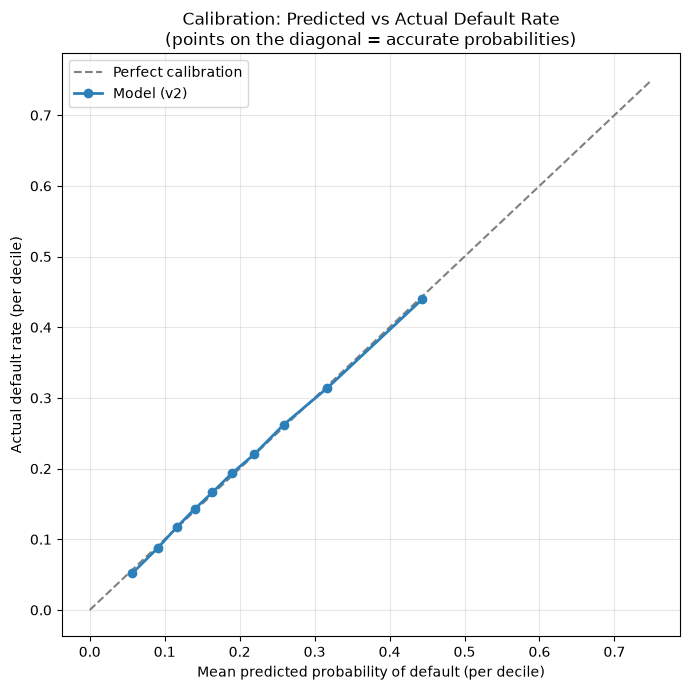

In [57]:
import matplotlib.pyplot as plt

cal_v2 = pd.DataFrame({"predicted": y_pred_proba_v2, "actual": y_test.values})
cal_v2["bucket"] = pd.qcut(cal_v2["predicted"], 10)
calib = cal_v2.groupby("bucket", observed=True).agg(
    avg_predicted=("predicted", "mean"),
    actual_rate=("actual", "mean"),
)

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 0.75], [0, 0.75], linestyle="--", color="grey",
        label="Perfect calibration")

ax.plot(calib["avg_predicted"], calib["actual_rate"],
        marker="o", color="#2c7fb8", linewidth=2,
        label="Model (v2)")

ax.set_xlabel("Mean predicted probability of default (per decile)")
ax.set_ylabel("Actual default rate (per decile)")
ax.set_title("Calibration: Predicted vs Actual Default Rate\n(points on the diagonal = accurate probabilities)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("calibration_plot.png", dpi=150, bbox_inches="tight")
plt.show()

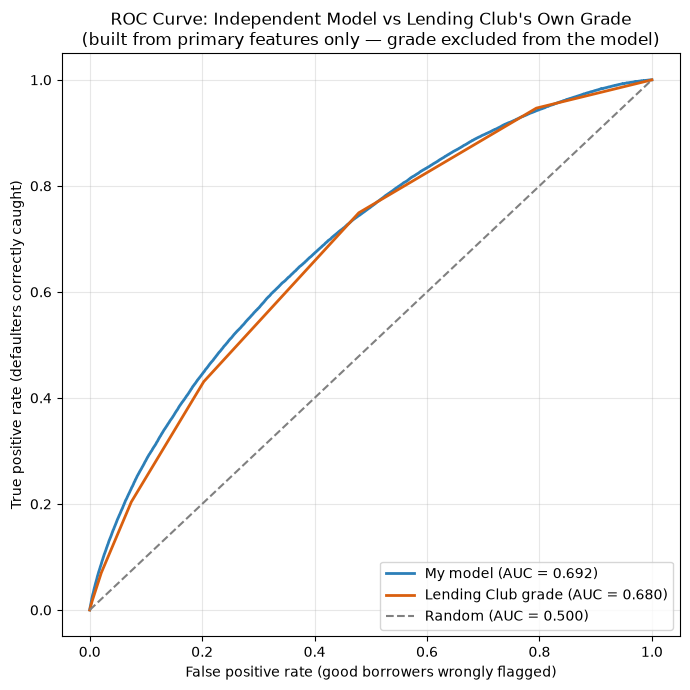

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_model, tpr_model, _ = roc_curve(y_test, y_pred_proba_v2)
auc_model = roc_auc_score(y_test, y_pred_proba_v2)

fpr_grade, tpr_grade, _ = roc_curve(y_test, grade_numeric)
auc_grade = roc_auc_score(y_test, grade_numeric)

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(fpr_model, tpr_model, color="#2c7fb8", linewidth=2,
        label=f"My model (AUC = {auc_model:.3f})")
ax.plot(fpr_grade, tpr_grade, color="#d95f0e", linewidth=2,
        label=f"Lending Club grade (AUC = {auc_grade:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey",
        label="Random (AUC = 0.500)")

ax.set_xlabel("False positive rate (good borrowers wrongly flagged)")
ax.set_ylabel("True positive rate (defaulters correctly caught)")
ax.set_title("ROC Curve: Independent Model vs Lending Club's Own Grade\n(built from primary features only — grade excluded from the model)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_vs_grade.png", dpi=150, bbox_inches="tight")
plt.show()

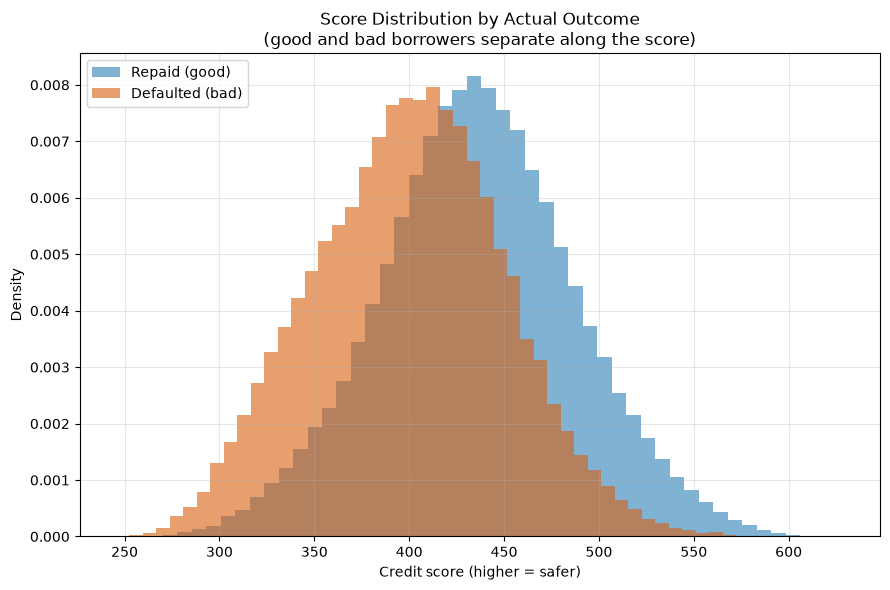

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

# split scores by actual outcome
scores_good = scores_v2[y_test.values == 0]
scores_bad = scores_v2[y_test.values == 1]

ax.hist(scores_good, bins=50, alpha=0.6, color="#2c7fb8",
        label="Repaid (good)", density=True)
ax.hist(scores_bad, bins=50, alpha=0.6, color="#d95f0e",
        label="Defaulted (bad)", density=True)

ax.set_xlabel("Credit score (higher = safer)")
ax.set_ylabel("Density")
ax.set_title("Score Distribution by Actual Outcome\n(good and bad borrowers separate along the score)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()